<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab7/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 7**

In [136]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
from scipy.stats import norm

## **Pregunta 1**

Descarga datos del IPSA desde https://www.investing.com/indices/ipsa-historical-data y léelos. ¿Cuántas observaciones y variables contiene el dataset? Muestra las primeras y últimas observaciones.

In [107]:
# URL raw del archivo Excel en GitHub
url_data = "https://raw.githubusercontent.com/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/refs/heads/main/Lab7/IPSA2019_2026.csv"

# Cargar el archivo Excel en un DataFrame de pandas
# header=None para indicar que el archivo no tiene una fila de encabezado
# names=column_names para asignar los nombres definidos
# index_col=None para evitar que pandas use alguna columna como índice
ipsa = pd.read_csv(url_data, index_col=None, decimal=',')

In [108]:
ipsa.shape

(1909, 7)

In [109]:
ipsa.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,08/31/2026,"11,315.26","11,445.90","11,456.30","11,301.01",NaN,-1.14%
1,08/28/2026,"11,445.90","11,470.79","11,564.91","11,418.98",NaN,-0.22%
2,08/27/2026,"11,470.79","11,369.18","11,470.79","11,369.18",NaN,0.89%
3,08/26/2026,"11,369.18","11,450.75","11,467.22","11,328.01",NaN,-0.71%
4,08/25/2026,"11,450.75","11,537.98","11,553.71","11,364.35",NaN,-0.76%


In [110]:
# Convertir la columna Fecha a datetime y ordenar de más antigua a más reciente
ipsa['Date'] = pd.to_datetime(ipsa['Date'])
ipsa = ipsa.sort_values(by='Date', ascending=True).set_index('Date')

In [111]:
ipsa.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2019-01-02,"5,125.37","5,125.37","5,137.32","5,064.41",278.00M,0.39%
2019-01-03,"5,129.15","5,129.15","5,146.30","5,097.21",NaN,0.07%
2019-01-04,"5,189.20","5,189.20","5,195.45","5,128.83",NaN,1.17%
2019-01-07,"5,190.06","5,190.06","5,221.37","5,181.86",NaN,0.02%
2019-01-08,"5,224.28","5,224.28","5,229.45","5,190.06",NaN,0.66%


In [112]:
ipsa.tail(10)

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2026-08-18,"11,186.57","11,147.83","11,199.93","11,101.12",NaN,0.34%
2026-08-19,"11,241.32","11,186.57","11,296.60","11,186.57",NaN,0.49%
2026-08-20,"11,237.90","11,241.32","11,286.86","11,172.27",NaN,-0.03%
2026-08-21,"11,338.38","11,238.59","11,393.20","11,238.59",NaN,0.89%
2026-08-24,"11,537.98","11,338.38","11,549.79","11,338.38",NaN,1.76%
2026-08-25,"11,450.75","11,537.98","11,553.71","11,364.35",NaN,-0.76%
2026-08-26,"11,369.18","11,450.75","11,467.22","11,328.01",NaN,-0.71%
2026-08-27,"11,470.79","11,369.18","11,470.79","11,369.18",NaN,0.89%
2026-08-28,"11,445.90","11,470.79","11,564.91","11,418.98",NaN,-0.22%


## **Pregunta 2**

Gráfica la evolución del IPSA para el período 2019-2026.

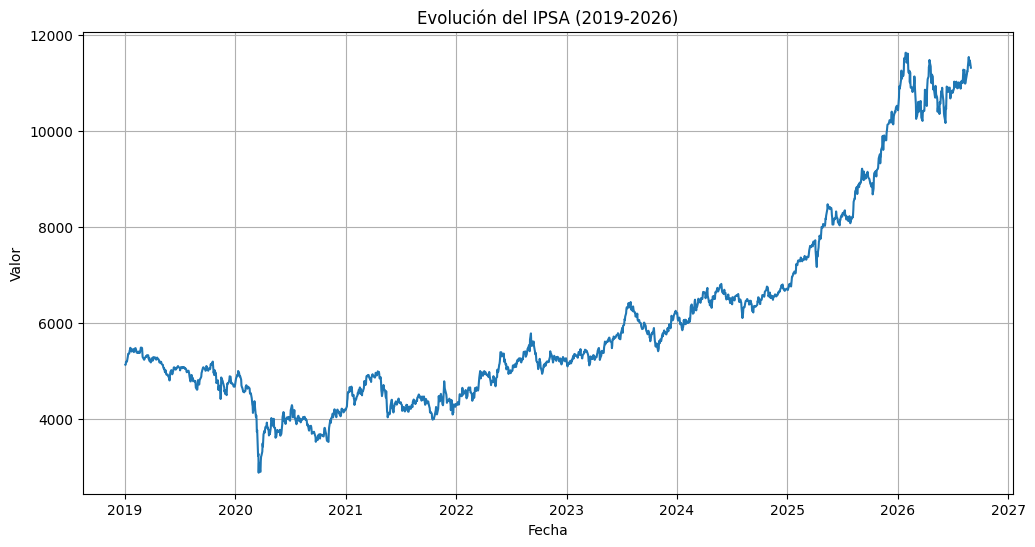

In [113]:
# Limpiar la columna 'Price' para eliminar comas y convertir a numérico
ipsa['Price'] = ipsa['Price'].str.replace(',', '').astype(float)

# Generar el gráfico de líneas
plt.figure(figsize=(12, 6))
plt.plot(ipsa.index, ipsa['Price'])
plt.title('Evolución del IPSA (2019-2026)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

## **Pregunta 3**

Calcula los retornos diarios del IPSA

In [114]:
returns = ipsa[['Price']].pct_change().dropna() * 100
# Añadir la columna 'day_of_week' al DataFrame prices
returns['day_of_week'] = returns.index.day_name()

returns.tail()

,Price,day_of_week
Date,,
2026-08-25,-0.756025,Tuesday
2026-08-26,-0.712355,Wednesday
2026-08-27,0.893732,Thursday
2026-08-28,-0.216986,Friday
2026-08-31,-1.141369,Monday


In [115]:
day_dummies = pd.get_dummies(returns['day_of_week'], dtype=int)
day_dummies.tail()

,Friday,Monday,Thursday,Tuesday,Wednesday
Date,,,,,
2026-08-25,0,0,0,1,0
2026-08-26,0,0,0,0,1
2026-08-27,0,0,1,0,0
2026-08-28,1,0,0,0,0
2026-08-31,0,1,0,0,0


In [116]:
# Unir las dummies de cada día de la semana y vuelta al DataFrame `prices`
returns = returns.join(day_dummies)

returns.tail(20)

,Price,day_of_week,Friday,Monday,Thursday,Tuesday,Wednesday
Date,,,,,,,
2026-08-04,-0.480742,Tuesday,0,0,0,1,0
2026-08-05,1.466199,Wednesday,0,0,0,0,1
2026-08-06,1.052727,Thursday,0,0,1,0,0
2026-08-07,-0.167359,Friday,1,0,0,0,0
2026-08-10,0.111760,Monday,0,1,0,0,0
2026-08-11,-1.245024,Tuesday,0,0,0,1,0
2026-08-12,-1.310502,Wednesday,0,0,0,0,1
2026-08-13,0.157975,Thursday,0,0,1,0,0
2026-08-14,0.387270,Friday,1,0,0,0,0


## **Pregunta 4**

Grafica la variaciones diarias del IPSA.

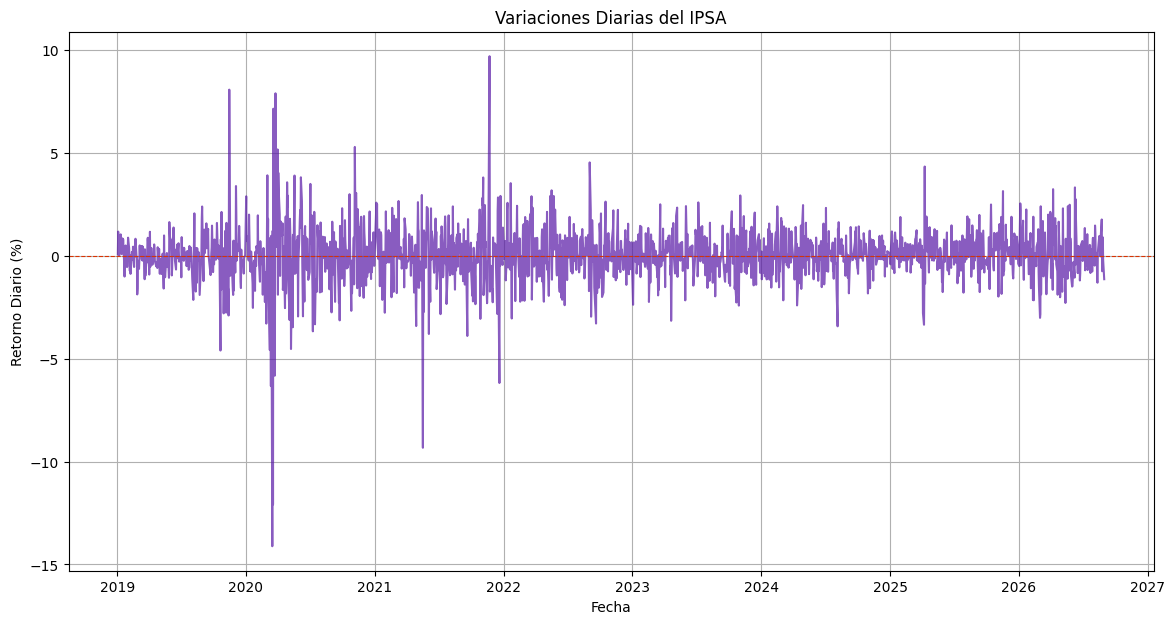

In [117]:
plt.figure(figsize=(14, 7))
plt.plot(returns.index, returns['Price'], color='#5717A6', alpha=0.7)
plt.title('Variaciones Diarias del IPSA')
plt.xlabel('Fecha')
plt.ylabel('Retorno Diario (%)')
plt.grid(True)
plt.axhline(0, color='#D93402', linestyle='--', linewidth=0.8) # Línea horizontal en y=0
plt.show()

## **Pregunta 5**

Construye un histograma de las variaciones porcentuales diarias del IPSA

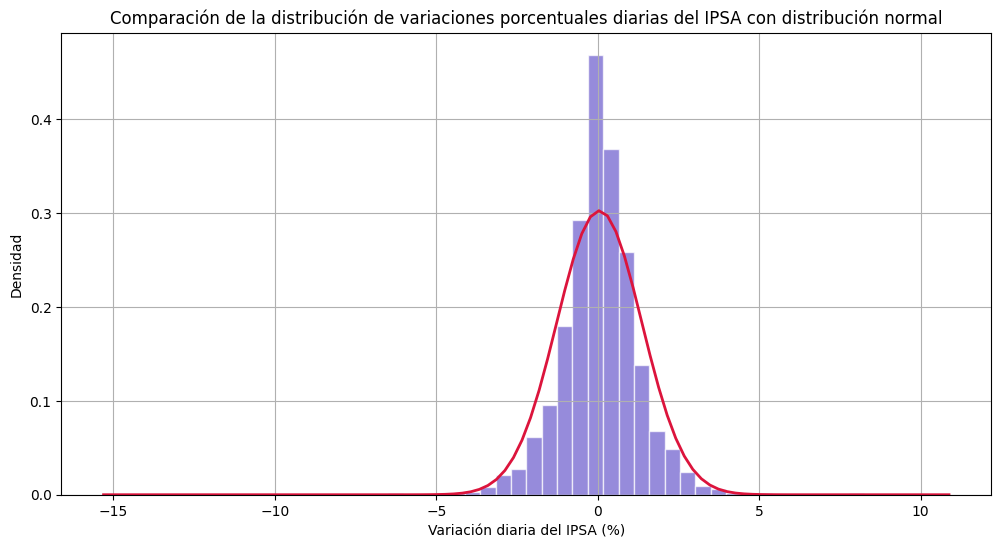

In [147]:
# Crear el histograma
plt.figure(figsize=(12, 6))
plt.hist(returns['Price'], bins=50, linewidth=1, density=True, alpha=0.7, color='#6A5ACD', edgecolor='white')

# Calcular la media y desviación estándar para la distribución normal
mu, std = returns['Price'].mean(), returns['Price'].std()

# Generar puntos para la curva de distribución normal
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Superponer la curva de distribución normal
plt.plot(x, p, linewidth=2, color='#DC143C')

plt.title('Comparación de la distribución de variaciones porcentuales diarias del IPSA con distribución normal')
plt.xlabel('Variación diaria del IPSA (%)')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

## **Pregunta 6**

Grafica el QQ-plot

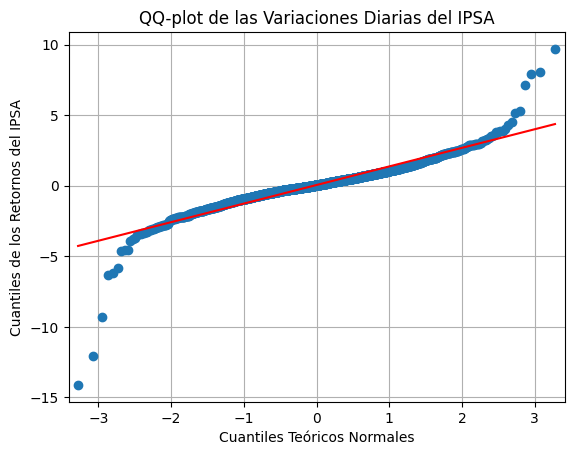

In [131]:
sm.qqplot(returns['Price'], line='s')
plt.title('QQ-plot de las variaciones diarias del IPSA')
plt.xlabel('Cuantiles teóricos normales')
plt.ylabel('Cuantiles de los retornos del IPSA')
plt.grid(True)
plt.show()

## **Pregunta 7**

Grafica un diagrama de caja para cada día de la semana.

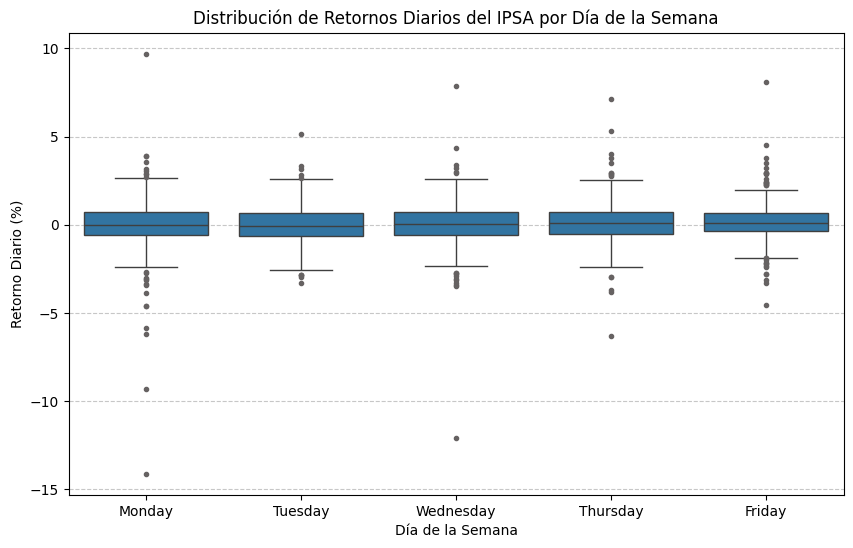

In [143]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_week', y='Price', data=returns, legend=False,
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'],
            flierprops=dict(marker='o', markersize=3,
                            markerfacecolor='#666262',
                            markeredgecolor='#666262'))
plt.title('Distribución de Retornos Diarios del IPSA por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Retorno Diario (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Pregunta 8**

¿Cuántas observaciones hay cada día de la semana?

In [66]:
returns['day_of_week'].value_counts()

,count
day_of_week,
Tuesday,388
Wednesday,385
Thursday,383
Monday,380
Friday,372


## **Pregunta 9**

Calcula el retorno promedio y desviación estándar para cada día de la semana.

In [130]:
returns.groupby('day_of_week')['Price'].agg(['mean', 'std'])

,mean,std
day_of_week,,
Friday,0.137199,1.158716
Monday,-0.056126,1.642628
Thursday,0.126024,1.220479
Tuesday,0.005716,1.124645
Wednesday,0.040829,1.371923


In [72]:
returns.shape # número de observaciones y variables

(1908, 7)

## **Pregunta 10**

Estima el siguiente modelo por MCO:

$$retorno = \alpha_0+\alpha_1 Lunes + \alpha_2 Martes +\alpha_3 Jueves +\alpha_4Viernes+\epsilon$$

Usando $\alpha=0.05$ ¿Qué *variables dummies* son estadísticamente significativas? Interpreta los coeficientes.

¿Qué puedes concluir de los valores del `F-statistic` y `Prob (F-statistic)`?

In [76]:
# Definir la variable dependiente (retornos del IPSA)
Y_IPSA = returns['Price']

# Definir las variables independientes: constante, Lunes, Martes, Jueves y Viernes
# Miércoles será el día base, por lo que su dummy se omite
# ¡Recuerda! Si la variable categórica día de la semana tiene 5 categorías, entonces se necesitan 4 dummies.
X1_noconstant = returns[['Monday','Tuesday', 'Thursday', 'Friday']]
X1 = sm.add_constant(X1_noconstant)

# Estimar el modelo OLS
model1 = sm.OLS(Y_IPSA, X1)   # Estimando el modelo con constante
results1 = model1.fit()

# Imprimir el resumen de los resultados
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.457
Date:                Thu, 03 Sep 2026   Prob (F-statistic):              0.213
Time:                        20:12:12   Log-Likelihood:                -3230.6
No. Observations:                1908   AIC:                             6471.
Df Residuals:                    1903   BIC:                             6499.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0408      0.067      0.608      0.5

Nota que:

$E(retorno|Lunes = 0, Martes = 0, Jueves = 0, Viernes = 0)=\widehat\alpha_0=0.0408$ (Retorno promedio de los miércoles)

$E(retorno|Lunes = 1, Martes = 0, Jueves = 0, Viernes = 0)=\widehat\alpha_0+\widehat\alpha_1=0.0408-0.0970=-0.0562$ (Retorno promedio de los lunes)

**(Compara con los retornos promedios calculados en *Pregunta 9*)**

## **Pregunta 11**

Si cambias la categoría base al día viernes, ¿cómo cambian los resultados?

Usando  α=0.05  ¿Qué variables dummies son estadísticamente significativas? Interpreta los coeficientes.

In [127]:
X1_noconstant = returns[['Monday','Tuesday', 'Wednesday', 'Thursday']]
X1 = sm.add_constant(X1_noconstant)

# Estimar el modelo OLS
model2 = sm.OLS(Y_IPSA, X1)   # Estimando el modelo con constante
results2 = model2.fit()

# Imprimir el resumen de los resultados
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.457
Date:                Thu, 03 Sep 2026   Prob (F-statistic):              0.213
Time:                        20:44:09   Log-Likelihood:                -3230.6
No. Observations:                1908   AIC:                             6471.
Df Residuals:                    1903   BIC:                             6499.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1372      0.068      2.009      0.0

Nota que:

$E(retorno|Lunes = 0, Martes = 0, Miercoles=0, Jueves = 0)=\widehat\alpha_0=0.1372$ (Retorno promedio de los viernes)

$E(retorno|Lunes = 1, Martes = 0, Miercoles=0, Jueves = 0)=\widehat\alpha_0+\widehat\alpha_1=0.1372-0.1933=-0.0561$ (Retorno promedio de los lunes)

**(Compara con los retornos promedios calculados en *Pregunta 9*)**

## **Pregunta 12**

Estima el siguiente modelo por MCO:

$$retorno = \beta_1 Lunes + \beta_2 Martes + \beta_3 Miercoles+\beta_4 Jueves +\beta_5Viernes+\epsilon$$

Usando $\alpha=0.05$ ¿Qué *variables dummies* son estadísticamente significativas? Interpreta los coeficientes.

In [129]:
# Estimar el modelo OLS
X1_noconstant = returns[['Monday','Tuesday', 'Wednesday', 'Thursday', 'Friday']]
model3 = sm.OLS(Y_IPSA, X1_noconstant)
results3 = model3.fit()

# Imprimir el resumen de los resultados
print(results3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.457
Date:                Thu, 03 Sep 2026   Prob (F-statistic):              0.213
Time:                        21:03:53   Log-Likelihood:                -3230.6
No. Observations:                1908   AIC:                             6471.
Df Residuals:                    1903   BIC:                             6499.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Monday        -0.0561      0.068     -0.831      0.4